# Linear Regression

## 1. Introduction

In univariate linear regression, we want to find suitable values for the parameters $w$ and $b$ so that the model

$$
f_{w,b}(x) = wx + b
$$

can make good predictions.

To determine these parameters automatically, we use an optimization algorithm called **Gradient Descent**. The purpose of this notebook is to develop an intuition for how this algorithm works and why it is able to find good model parameters.

Geometrically, linear regression tries to fit a line to a dataset. It is appropriate when the data shows an approximately linear relationship.

Before running the notebook, execute the code cell below to import the required dependencies and generate an example dataset we will be working with in this notebook.

In [8]:
import matplotlib.pyplot as plt

from utils.helpers import (
    generate_study_hour_dataset,
    fit_linear_regression_model,
    simple_cost_curve, 
    tangent_line,
    compute_cost_history,
    compute_gradient_descent_path,
)

from utils.plotting import (
    plot_dataset, 
    plot_errors, 
    plot_simple_cost_function,
    plot_cost_point,
    plot_model_comparison,
    plot_tangent,
    plot_cost_history,
    plot_3D_surface,
    plot_contour,
    plot_gradient_descent_path,
)

x, y = generate_study_hour_dataset()

The dataset maps the input feature $x$ (study hours) to the target value $y$ (exam scores) over 20 training examples.

Run the next code cell to visualize the dataset with a scatter plot.

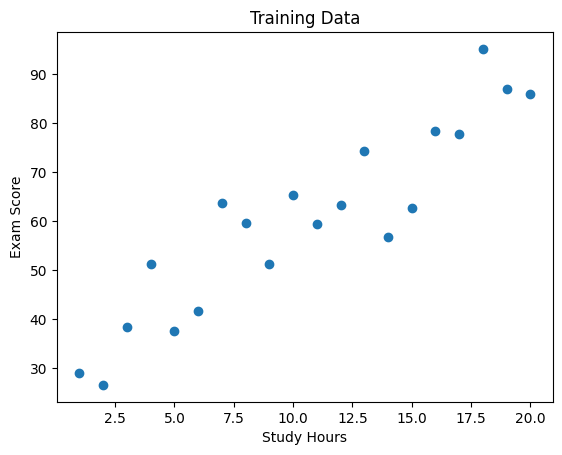

In [9]:
plot_dataset(x, y)

plt.show()

At first glance, the data appears to have an approximately linear relationship, which makes it suitable for linear regression.

If we try different lines manually, we need a way to evaluate how well each line fits the data. For this purpose, we use the cost function

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$$

The smaller the cost, the better the line fits the dataset. Therefore, our goal is to find the values of $w$ and $b$ that minimize $J(w,b)$.

Trying many different values manually would quickly become cumbersome. Gradient Descent provides a systematic way to search for parameters that minimize the cost function.

The plot below shows the dataset again, but this time with an additional line representing a poorly chosen model.

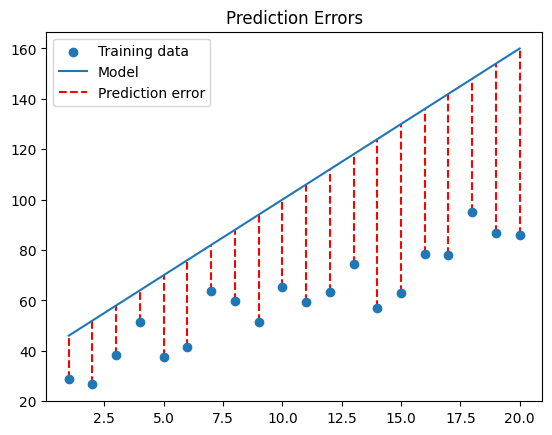

In [10]:
w_bad = 6.0
b_bad = 40.0

plot_errors(x, y, w_bad, b_bad)

plt.legend()
plt.show()

The red vertical lines represent the prediction errors. Before reading on, take a moment to inspect the plot. Do you think the model overestimates or underestimates the exam scores?

With the current values of $w=6.0$ and $b=40.0$, the model is too optimistic and consistently overestimates the exam scores.

## 2. The Cost Function

As we have seen in the previous example, an overly optimistic model is not suitable for predicting exam scores. Therefore, we need to find better values for the model parameters $w$ and $b$ so that the regression line fits the data more accurately.

The plot below shows the result after applying Gradient Descent to our dataset. Compared to the previous model, the regression line fits the data much better.

Before we look at the Gradient Descent algorithm itself, we first need to understand the cost function. Gradient Descent uses the cost function to evaluate different choices of the model parameters.

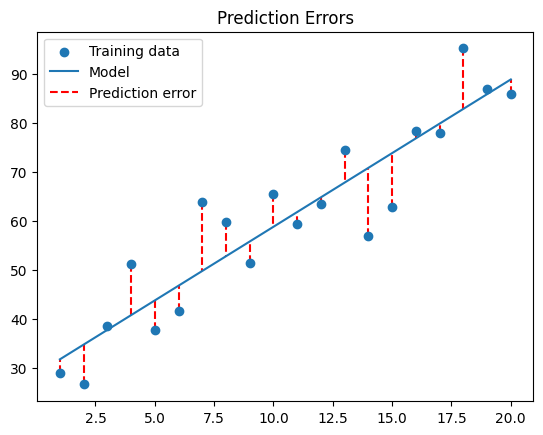

In [11]:
w_good, b_good = fit_linear_regression_model(x, y)

plot_errors(x, y, w_good, b_good)

plt.legend()
plt.show()

Gradient Descent computes the model parameters approximately as
$w = 3.00$ and $b = 28.74$.

If you compare the prediction error plots of the good and the bad model, you will notice that the red error lines are much shorter for the model obtained by Gradient Descent.

Let's have a closer look at the cost function to understand how it computes the cost. There is no need to memorize the formula, so here it is again:

$$
J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$$

For every training example, we compute the difference between the predicted value $f_{w,b}(x^{(i)})$ and the actual value $y^{(i)}$. These differences are squared so that positive and negative errors contribute equally to the total cost. Finally, we sum all squared errors.

To obtain the final cost, we divide the sum by $2m$, where $m$ denotes the number of training examples. Dividing by $m$ gives the average squared error, making the cost independent of the size of the training set. The additional factor of $2$ is introduced because it simplifies the derivative used by Gradient Descent.

Although the cost function actually depends on two parameters, we will first simplify the problem by considering only one parameter. This allows us to understand how the key ideas behind Gradient Descent before returning to the full cost function later.

## 3. A Simpler Problem: $J(w)$

To develop an intuition for Gradient Descent, we first consider a simplified version of the model by fixing the intercept to $b = 0$. The linear regression model then becomes

$$
f_w(x) = wx.
$$

Consequently, the cost function also depends on only one parameter:

$$
J(w) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_w(x^{(i)}) - y^{(i)}\right)^2.
$$

The plot below shows this simplified cost function together with its minimum.

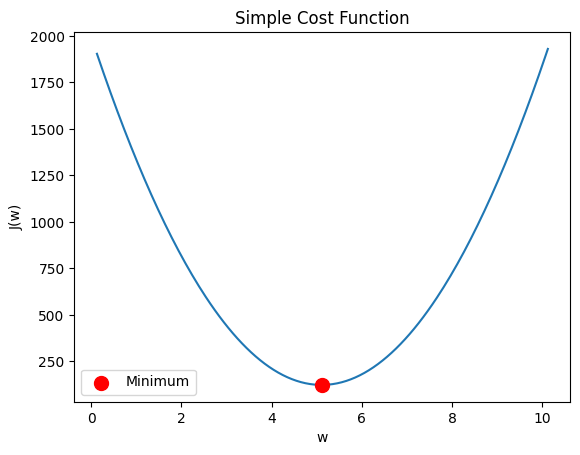

In [12]:
w_values, costs, w_min = simple_cost_curve(x, y)

plot_simple_cost_function(w_values, costs)
plot_cost_point(x, y, w=w_min, color="red", s=100, label="Minimum")

plt.legend()
plt.show()

Here, the parameter $w$ is shown on the x-axis and the cost $J(w)$ on the y-axis. Because the prediction errors are squared, the cost function forms a parabola. The minimum is located at approximately $w = 5.13$.

By looking at the plot, do you think this simplified model can make the best possible predictions?

Although the simplified model can still fit the data reasonably well, we can see that its minimum is greater than zero. If the minimum had a cost value that is equal to zero, the parabola would touch the x-axis, meaning that the model predicts every training example perfectly.

In practice, however, our simplified model is restricted because the intercept is fixed to zero. Later, we will return to the complete cost function $J(w,b)$ and see that allowing both parameters to vary leads to a lower minimum.

At the end of this chapter I don't want to miss the opertunity to show you a comparison of the three models we have observed so far in the next plot.

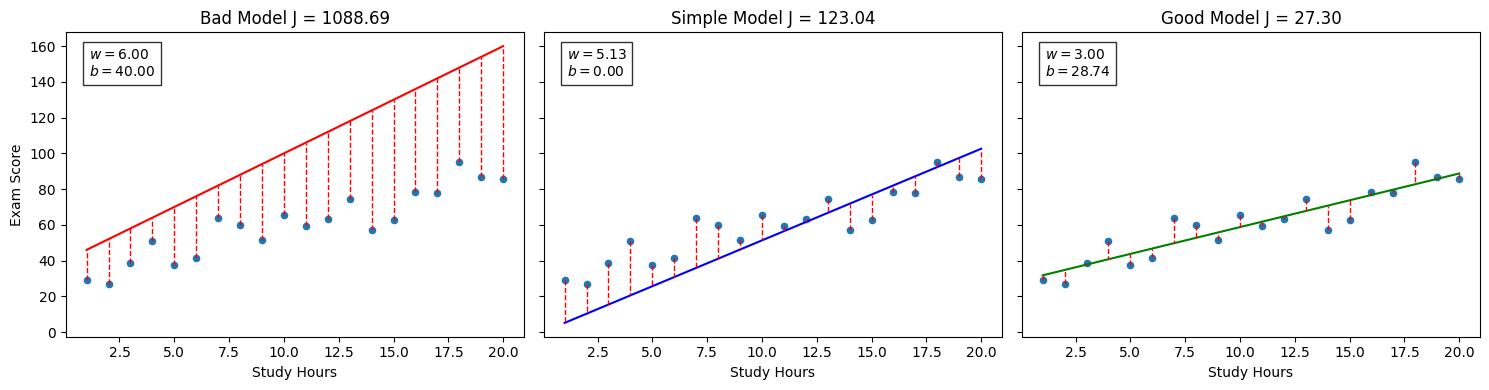

In [13]:
model_params = [
    ("Bad Model", 6.0, 40.0, "red"),
    ("Simple Model", 5.13, 0.0, "blue"),
    ("Good Model", 3.0, 28.74, "green")
]

plot_model_comparison(x, y, model_params)

plt.show()

## 4. Derivative and Slope


The Gradient Descent algorithm does not analyze the entire cost function at once as we did in the previous chapter by looking at a plot of the cost function. Instead, it is an iterative optimization algorithm that moves closer to the minimum one step at a time.

To begin the optimization, we first choose an initial value for the parameter $w$. The algorithm then repeatedly updates this value until it reaches the minimum of the cost function.

Next we will go through an examplatory update step of the algorithm together and see what it does. For the example we will take our simple cost function from before and choose the initial value $w = 8$

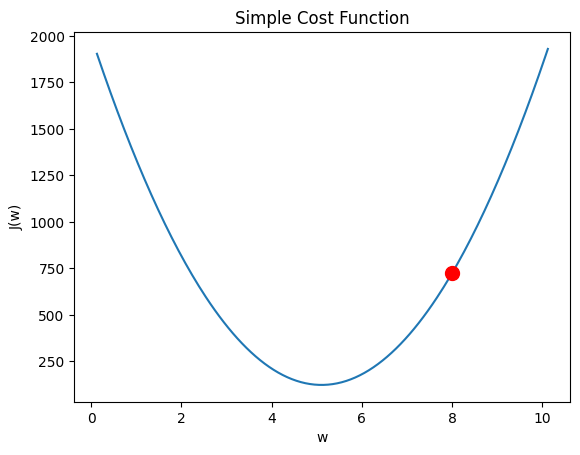

In [14]:
plot_simple_cost_function(w_values, costs)
plot_cost_point(x, y, w=8, color="red", s=100, label=None)

plt.show()

If you could guide the algorithm using the information you see in the plot, in which direction would you send it?

Exactly, we would move towards the minimum.

The algorithm determines this direction by computing the slope of the cost function at the current value of $w$.

In calculus, this slope is called the **first derivative** and is written as

$$
\frac{dJ}{dw}.
$$

The derivative measures how much the cost $J(w)$ changes in response to a very small change in $w$. In other words, it describes the rate of change of the cost function at the current point.

Using the rules of differential calculus, in particular the chain rule, the derivative of our simplified cost function becomes

$$
\frac{dJ}{dw}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(f_w(x^{(i)})-y^{(i)}\right)x^{(i)}.
$$

In the plot below, we use this expression to compute the derivative at $w = 8$. The corresponding slope is visualized by the tangent line.

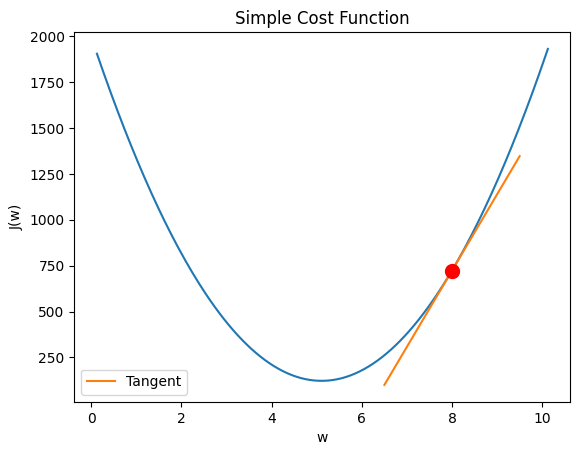

In [8]:
plot_simple_cost_function(w_values, costs)
plot_cost_point(x, y, w=8, color="red", s=100, label=None)

w_tangent, j_tangent = tangent_line(x, y, w0=8)
plot_tangent(w_tangent, j_tangent)

plt.legend()
plt.show()

In our example, the slope is positive. This means that the cost function increases when we move to the right. Therefore, the algorithm has to move in the opposite direction, making $w$ smaller in order to approach the minimum.

You can also imagine that a steeper slope results in a larger update of $w$. However, the size of each update is not determined by the slope alone. Later, we will introduce another parameter, the learning rate $\alpha$, which allows us to control how large each update should be.

For now, let's see what happens when the slope is negative.

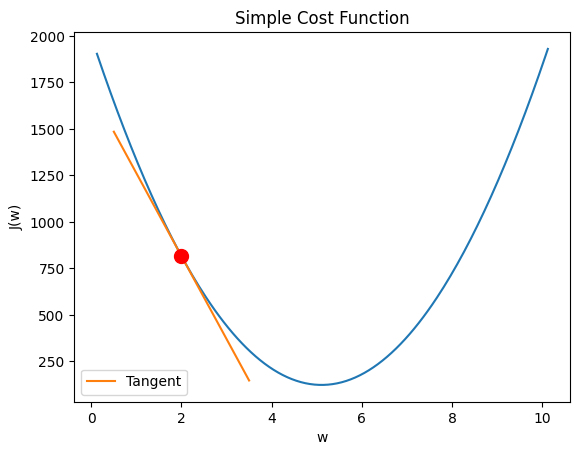

In [9]:
plot_simple_cost_function(w_values, costs)
plot_cost_point(x, y, w=2, color="red", s=100, label=None)

w_tangent, j_tangent = tangent_line(x, y, w0=2)
plot_tangent(w_tangent, j_tangent)

plt.legend()
plt.show()

In this case, the slope is negative. To move towards the minimum, the algorithm now has to increase the value of $w$.

Notice that the rule has not changed: Gradient Descent always moves in the opposite direction of the slope. A positive slope decreases $w$, whereas a negative slope increases $w$.

## 5. Gradient Descent Update Rule

We can now formulate a single update step of the Gradient Descent algorithm as

$$
w_{\text{temp}} = w - \alpha \frac{dJ}{dw}.
$$

Starting from an initial value of $w$, Gradient Descent repeatedly applies this update rule to move closer to the minimum of the cost function.

Notice that the update rule always subtracts the derivative. This automatically produces the correct behavior. If the slope is positive, $w$ becomes smaller. If the slope is negative, subtracting a negative value is equivalent to adding a positive value, causing $w$ to increase. In both cases, the algorithm moves towards the minimum.

The parameter $\alpha$, called the **learning rate**, controls the size of each update. A larger learning rate results in bigger steps, whereas a smaller learning rate produces more cautious updates.

From an implementation perspective, two additional steps are required. After computing the new parameter value, we update

$$
w = w_{\text{temp}},
$$

and repeat the procedure inside a loop. The number of iterations determines how many update steps the algorithm performs before it terminates.

## 6. Convergence

The plot below shows how the cost changes during Gradient Descent when starting with the initial value $w = 8$.

With every update, the algorithm moves closer to the minimum of the cost function and the cost decreases accordingly. After approximately 200 iterations, the algorithm has converged and further updates become negligibly small.

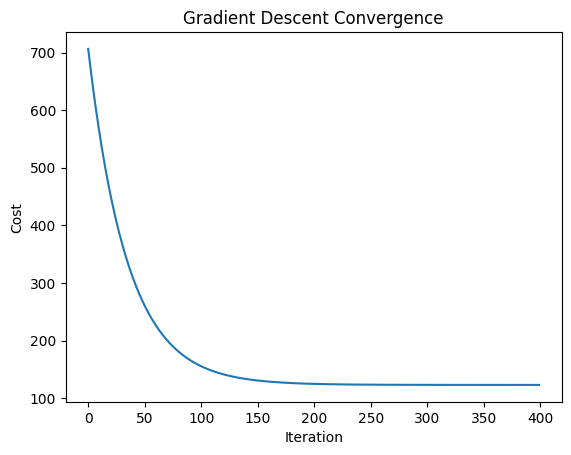

In [10]:
cost_history = compute_cost_history(x, y, w=8)
plot_cost_history(cost_history)

plt.show()

Why doesn't the cost decrease any further?

As the algorithm approaches the minimum, the slope becomes very small. Consequently, the parameter updates become negligible. At the minimum, the slope is zero, so Gradient Descent has converged.

## 7. Extending to $J(w, b)$

By now, you should have a good intuition for how Gradient Descent finds the minimum of the cost function when optimizing a single parameter $w$.

We can now return to the complete linear regression model

$$
f_{w,b}(x) = wx + b.
$$

Reintroducing the intercept $b$ makes the model much more flexible. In the simplified model, every regression line passed through the origin because we fixed $b = 0$. Allowing both parameters to vary enables the model to fit the training data much more accurately.

With two parameters, the cost function is no longer a curve but a three-dimensional surface. The plot below shows the actual cost surface of our training dataset.

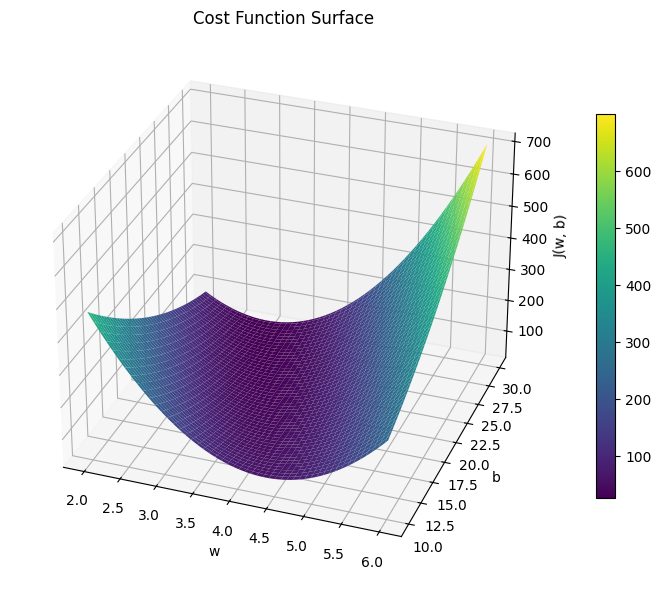

In [5]:
plot_3D_surface(x, y)

plt.show()

The plot above shows the cost function in three dimensions. The horizontal axes represent the model parameters $w$ and $b$, while the vertical axis represents the corresponding cost $J(w,b)$.

Every point on the surface corresponds to one possible choice of the model parameters $w$ and $b$. The height of the surface represents the value of the cost function $J(w,b)$. The lowest point on the surface therefore corresponds to the parameter values that minimize the cost.

Can you already guess how Gradient Descent will move across this surface?

## 8. Contour Plot

To better understand the three-dimensional cost surface we can look at it from above using a contour plot.

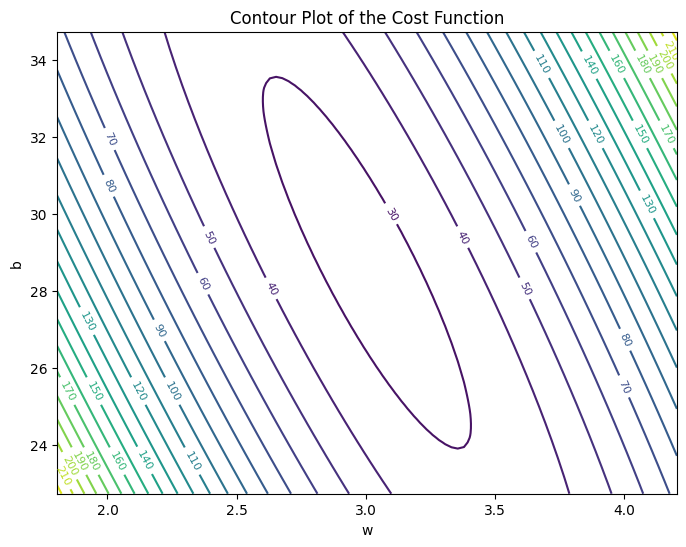

In [6]:
plot_contour(x, y)
plt.show()

Each contour line represents points with the same value of the cost function $J(w,b)$. You can think of it like a topographic map, where each contour line connects points at the same elevation.

In this representation, it is much easier to identify the location of the minimum. The center of the contour lines corresponds to the lowest point of the cost function.

The contour plot also makes it easier to imagine how Gradient Descent moves across the cost surface towards the minimum.

## 9. Partial Derivatives

Fortunately, extending Gradient Descent to the complete cost function does not require many changes. Since the cost function now depends on two parameters, we simply update both parameters simultaneously:

- $w_{\text{temp}} = w - \alpha \frac{\partial J}{\partial w}$
- $b_{\text{temp}} = b - \alpha \frac{\partial J}{\partial b}$

Instead of measuring the slope in one direction, we now have to measure how the cost changes in two independent directions: one with respect to w and one with respect to b.

The key difference is that we now use **partial derivatives** instead of an ordinary derivative. Because the cost function $J(w,b)$ depends on both $w$ and $b$, we need one partial derivative with respect to $w$ and another with respect to $b$.

As before, these derivatives can be obtained by applying the chain rule from calculus. This results in

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)}-y^{(i)}\right)x^{(i)}
$$

and

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)}-y^{(i)}\right).
$$

Together, these two partial derivatives form the gradient of the cost function.

## 10. Full Gradient Descent

The two partial derivatives indicate how the cost changes when we vary $w$ or $b$ individually. Together, they form the gradient of the cost function:

$$
\nabla J(w,b)
=
\begin{bmatrix}
\frac{\partial J}{\partial w} \\
\frac{\partial J}{\partial b}
\end{bmatrix}
$$

The **gradient** is a vector. It points in the direction of steepest ascent, meaning the direction in which the cost increases most rapidly. The magnitude of the gradient reflects the steepness of the cost surface at that point: the larger the magnitude, the steeper the surface.

Gradient Descent moves in the opposite direction of the gradient in order to reduce the cost.

The plot below shows the update path of Gradient Descent on the cost surface of our training dataset.

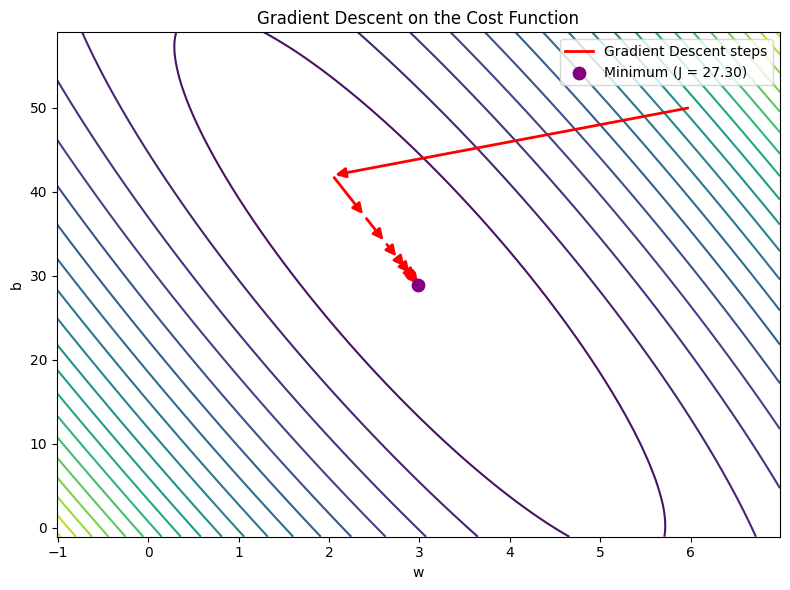

In [2]:
w_start = 6
b_start = 50
alpha = 0.01
iterations = 2000
arrow_every = 200

path_w, path_b = compute_gradient_descent_path(x, y, w_start, b_start, alpha, iterations)
plot_gradient_descent_path(x, y, path_w, path_b, arrow_every)

plt.show()

The red arrows represent the successive parameter updates. Starting from an initial point, the algorithm repeatedly updates $w$ and $b$ until it approaches the minimum. The learning rate $\alpha$ influences the size of each update, but it is not the only factor. The update size also depends on the magnitude of the gradient. Far from the minimum, the cost surface is steeper and the gradient is larger, resulting in bigger update steps. As the algorithm approaches the minimum, the surface becomes flatter, the gradient decreases, and the update steps automatically become smaller.

Although Gradient Descent performs 2000 parameter updates, displaying every update would clutter the figure. Therefore, only every 200th update is shown. You can change the arrow_every parameter to display the optimization path with a different level of detail.

Feel free to also experiment with the starting point, the learning rate, the number of iterations to explore how Gradient Descent behaves.

Thank you for working through this notebook. I hope it helped you build an intuitive understanding of Gradient Descent.